# Visualize

> Data visualization

In [11]:
#| default_exp visualize

In [12]:
#| hide
from nbdev.showdoc import *

In [13]:
#| export
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly
import plotly.express as px
from skimage import exposure, util
from skimage.data import cells3d
import torchvision

from fastai.vision.all import plt, ifnone

from bioMONAI.core import torchTensor, tensor, delegates, torch_from_numpy, hasattrs
from bioMONAI.io import tiff2torch

In [14]:
# load sample data
data = util.img_as_float(cells3d()[:, 1, :, :])  # load the nuclei channel

## Display 3D images

Function to display the 3D volume in axial, coronal or sagittal reconstruction. The display functions does not consider the spacing between pixels, so reconstructions may look unusual. 

In [15]:
#| export
# Utility function for determining figure bounds
def _fig_bounds(x):
    r = x//8
    return min(15, max(1,r))

In [16]:
#| export
def mosaic_image_3d(t: (np.ndarray, torchTensor),
                  axis: int = 0,
                  figsize: tuple = (15,15),
                  cmap: str = 'gray',
                  nrow: int = 10,
                  alpha = 1.,
                  return_grid = False,
                  add_to_existing = False,
                  **kwargs):
    '''
    Plots 2D slices of a 3D image alongside a prior specified axis.
    Args:
        t: a 3D numpy.ndarray or torch.Tensor
        axis: axis to split 3D array to 2D images
        figsize, cmap: passed to plt.imshow
        nrow: passed to torchvision.utils.make_grid
        return_grid: Whether the grid should be returned for further processing or if the plot should be displayed.
        add_to_existing: if set to true, no new figure will be created. Used for mask overlays
    '''
    if isinstance(t, np.ndarray): 
        t = tensor(t)
    
    if t.device.type == 'cuda': 
        t = t.cpu()
    
    if t.ndim < 3 or t.ndim > 4:
         raise TypeError('Object is not a rank 3 tensor but a rank {} tensor'.format(t.ndim ))
    if t.ndim == 4:
        t = t[0]

    if axis == 1: 
        t = np.transpose(t, (1, 0, 2))
    elif axis == 2: 
        t = np.transpose(t, (2, 0, 1))

    if t.min() < 0.:
        t = t - t.min()  # shift pixel values to positive range, otherwise the negative values will be clipped.

    t = t.unsqueeze(1)/t.max()  # rescale the images, makes for a nicer plot
    grid = torchvision.utils.make_grid(t, nrow=nrow)

    if return_grid:
        return grid

    if figsize is None:
        figsize = (_fig_bounds(t.shape[2]), _fig_bounds(t.shape[3]))

    if not add_to_existing:
        plt.figure(figsize=figsize)

    plt.imshow(grid[0,:,:], cmap=cmap, alpha=alpha)
    plt.axis('off')

In [17]:
#| export
@delegates(plt.Axes.imshow, keep=True, but=['shape', 'imlim'])
def show_images_grid(images, ax=None, ncols=10, figsize=None, title=None, spacing=0.02, max_slices=3, ctx=None, **kwargs):
    """
    Show a list of images arranged in a grid.

    Parameters:
    - images: list of images to display.
    - ncols (int): number of columns in the grid.
    - figsize (tuple, optional): figure size in inches.
    - titles (list, optional): list of titles corresponding to each image.
    - spacing (float, optional): spacing between subplots.
    - ctx: additional context passed to the `plt.Axes.imshow` function.
    - **kwargs: additional keyword arguments passed to `plt.Axes.imshow`.

    Returns:
    - axes: matplotlib axes containing the grid of images.
    """

    # Ensure images is a list
    images = list(images)

    # Compute number of rows needed based on number of columns and images
    n_images = len(images)
    nrows = (n_images - 1) // ncols + 1

    # Compute figure size if not provided
    if figsize is None:
        fig_width = ncols * (1 + spacing) - spacing
        fig_height = nrows * (1 + spacing) - spacing
        figsize = (fig_width, fig_height)

    ax = ifnone(ax,ctx)
    
    if ax is None:
        fig, ax = plt.subplots(nrows, ncols, figsize=figsize)
        fig.subplots_adjust(wspace=spacing, hspace=spacing) # Adjust spacing between subplots
    ax = np.atleast_2d(ax)

    # Turn off axes for all subplots
    for axis in ax.flatten():
        axis.axis('off')

    # Iterate over images and corresponding axes
    for i, (im, axis) in enumerate(zip(images, ax.flatten())):
        # Convert input to numpy array if necessary
        if isinstance(im, np.ndarray):
            im_to_show = im
        elif hasattrs(im, ('data', 'cpu', 'permute')):
            im_to_show = im.data.cpu()
            if im_to_show.ndim == 3:
                num_slices = im_to_show.shape[0]
                if num_slices < max_slices:
                    im_to_show = np.concatenate([im_to_show[i] for i in range(num_slices)], axis=1)
                else:
                    # showing middle slice
                    im_to_show = im_to_show[num_slices // 2]
            elif im_to_show.ndim == 4:
                im_to_show = im_to_show[0]
        else:
            im_to_show = array(im)

        # Display image on current axes
        axis.imshow(im_to_show, **kwargs)
        if title is not None and i < len(title):
            axis.set_title(title[i])

    # Hide unused axes
    for axis in ax.flatten()[n_images:]:
        axis.set_visible(False)

    return ax

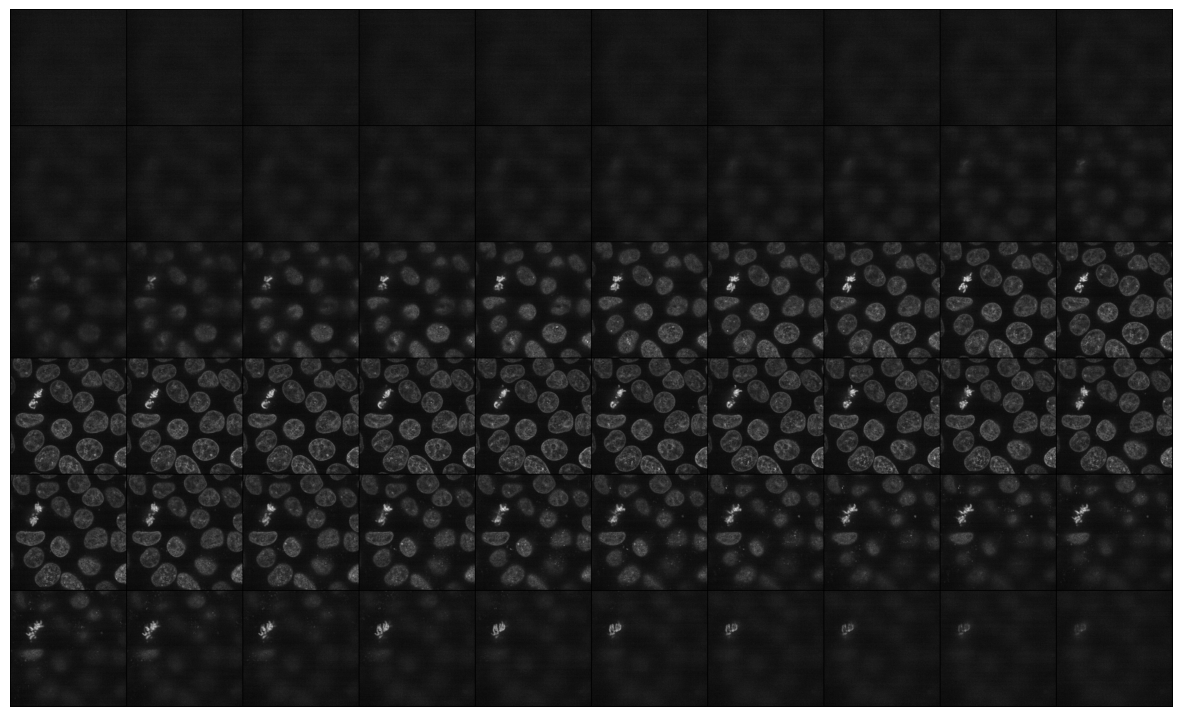

In [18]:
mosaic_image_3d(torch_from_numpy(data), figsize=None)

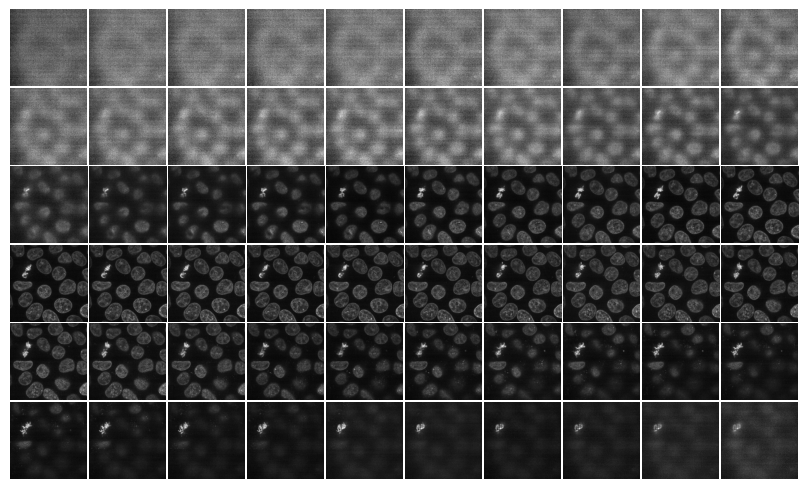

In [19]:
show_images_grid(data, cmap='gray');

In [20]:
#| export
def show_plane(ax, plane, cmap="gray", title=None, lines=None, linestyle='--', linecolor='white'):
    """
    Display a slice of the image tensor on a given axis with optional dashed lines.
    
    Parameters:
        ax (matplotlib.axes._subplots.AxesSubplot): The axis object to display the slice on.
        plane (numpy.ndarray): A 2D numpy array representing the slice of the image tensor.
        cmap (str, optional): Colormap to use for displaying the image. Defaults to "gray".
        title (str, optional): Title for the plot. Defaults to None.
        dashed_lines (list, optional): A list of indices where dashed lines should be drawn on the plane.
    """
    ax.imshow(plane, cmap=cmap)
    ax.set_axis_off()
    
    if title:
        ax.set_title(title)
    
    # Add dashed lines if specified
    if lines is not None:
        ax.axhline(lines[0], color=linecolor, linestyle=linestyle)
        ax.axvline(lines[1], color=linecolor, linestyle=linestyle)


In [21]:
#| export
def visualize_slices(data, planes=None, showlines=True, **kwargs):
    """
    Visualize slices of a 3D image tensor along its planes, rows, and columns.
    
    Parameters:
        data (numpy.ndarray): A 3D numpy array representing the image tensor.
        planes (tuple): A tuple containing the indices of the planes to visualize. If None, defaults to middle slices.
    """
    if planes:
        z, y, x = planes
    else:
        # Extract dimensions
        (z, y, x) = data.shape
        z = z // 2
        y = y // 2
        x = x // 2
    
    # Create subplots
    _, (a, b, c) = plt.subplots(ncols=3, figsize=(15, 5))
    
    # Display slices along planes, rows, and columns
    if showlines:
        show_plane(a, data[z], title=f'Plane = {z}', lines=[y, x], **kwargs)
        show_plane(b, data[:, y, :], title=f'Row = {y}', lines=[z, x], **kwargs)
        show_plane(c, data[:, :, x], title=f'Column = {x}', lines=[z, y], **kwargs)
    else:
        show_plane(a, data[z], title=f'Plane = {z}')
        show_plane(b, data[:, y, :], title=f'Row = {y}')
        show_plane(c, data[:, :, x], title=f'Column = {x}')
    
    # Show the plot
    plt.show()


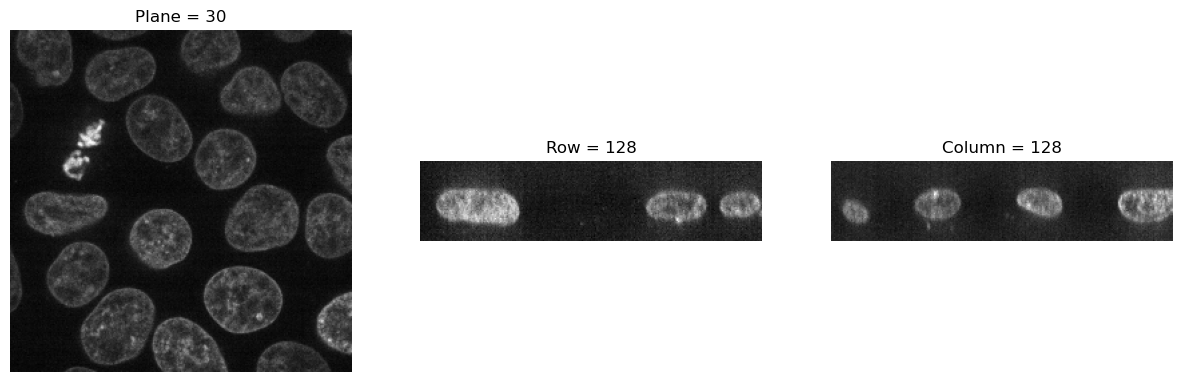

In [22]:
visualize_slices(data, showlines=False)

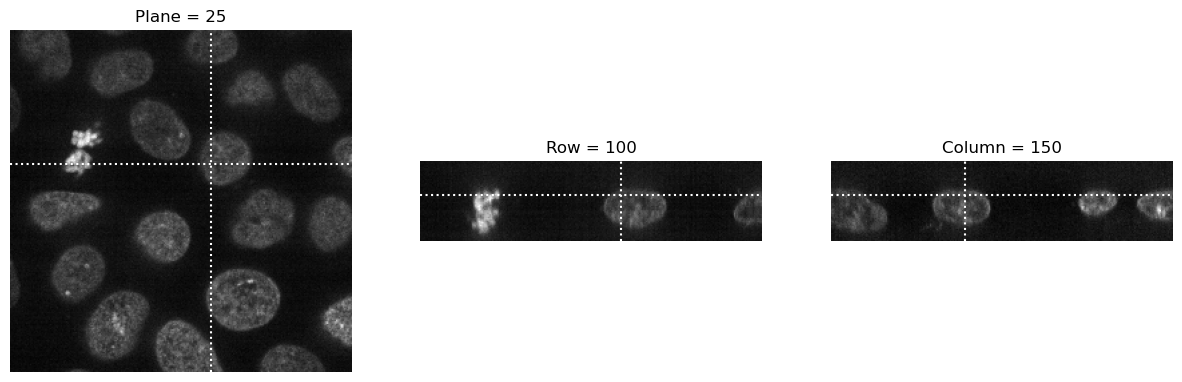

In [27]:
visualize_slices(data, (25,100,150), linestyle=':')

In [24]:
#| hide
import nbdev; nbdev.nbdev_export()